SECTION 1 — Introduction
# Bitcoin Market Sentiment vs Trader Performance Analysis

## Objective
This project analyzes the relationship between Bitcoin market sentiment
(Fear & Greed Index) and trader performance using Hyperliquid historical trading data.

The goal is to identify patterns between market emotions and trading behavior,
including profitability, trading activity, and trader performance.

SECTION 2 — Data Loading

In this section, we import required libraries and load the datasets.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sentiment = pd.read_csv('fear.csv')
trades = pd.read_csv('historical.csv')
print(sentiment.head())
print(sentiment.columns)

print(trades.head())
print(trades.columns)

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      

SECTION 3 — Data Cleaning

The datasets are cleaned and date columns are converted into proper datetime format
for accurate analysis and merging.

In [39]:
# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Convert trading timestamp
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)
# Extract only date
sentiment['date_only'] = sentiment['date'].dt.date

trades['date_only'] = trades['Timestamp IST'].dt.date


SECTION 4 — Data Merging
# Data Merging

The trading dataset and market sentiment dataset are merged
using the common date column.

In [40]:
merged = pd.merge(
    trades,
    sentiment,
    on='date_only',
    how='left'
)

print(merged.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  5201

SECTION 5 — Exploratory Data Analysis (EDA)
# Exploratory Data Analysis

This section explores trader performance and behavior under different market sentiments.

In [30]:
profit_analysis = merged.groupby('classification')['Closed PnL'].mean()

print(profit_analysis)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


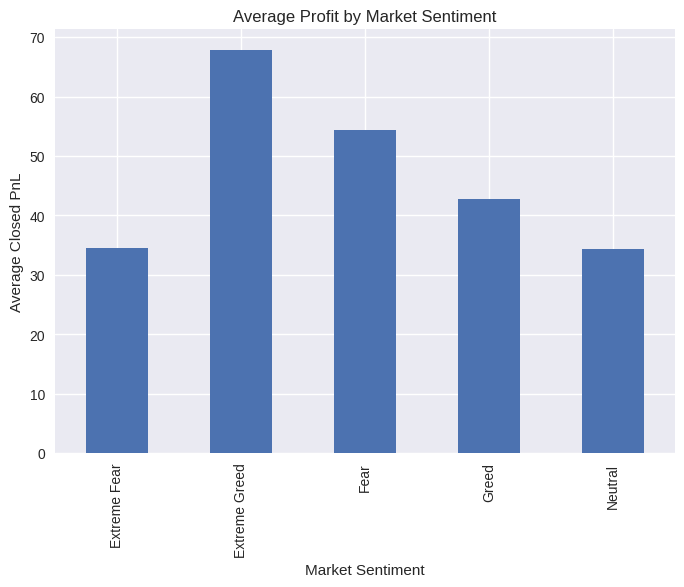

In [31]:
profit_analysis.plot(kind='bar')

plt.title('Average Profit by Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.xlabel('Market Sentiment')

plt.show()

In [41]:
#Trade Count
trade_count = merged['classification'].value_counts()

print(trade_count)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


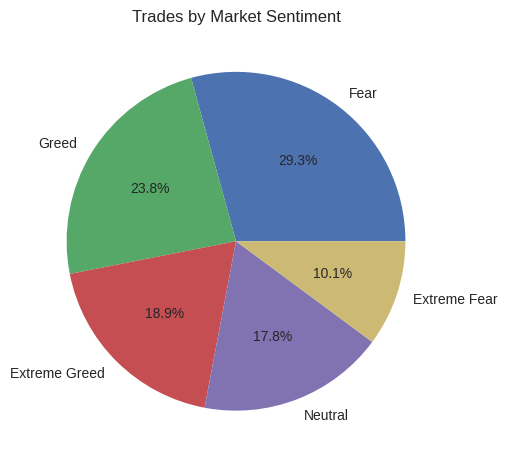

In [33]:
#Pie Chart
trade_count.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Trades by Market Sentiment')
plt.ylabel('')

plt.show()

In [34]:
#Buy/Sell Performance
side_analysis = merged.groupby(
    ['classification', 'Side']
)['Closed PnL'].mean()

print(side_analysis)

classification  Side
Extreme Fear    BUY      34.114627
                SELL     34.980106
Extreme Greed   BUY      10.498927
                SELL    114.584643
Fear            BUY      63.927104
                SELL     45.049641
Greed           BUY      25.002302
                SELL     59.691091
Neutral         BUY      29.227429
                SELL     39.456408
Name: Closed PnL, dtype: float64


SECTION 6 — Visualizations
# Visualizations

Charts are used to better understand the relationship between
market sentiment and trading behavior.

In [35]:
#Fee Analysis
fee_analysis = merged.groupby(
    'classification'
)['Fee'].mean()

print(fee_analysis)

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64


In [36]:

top_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(
    ascending=False
).head(10)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


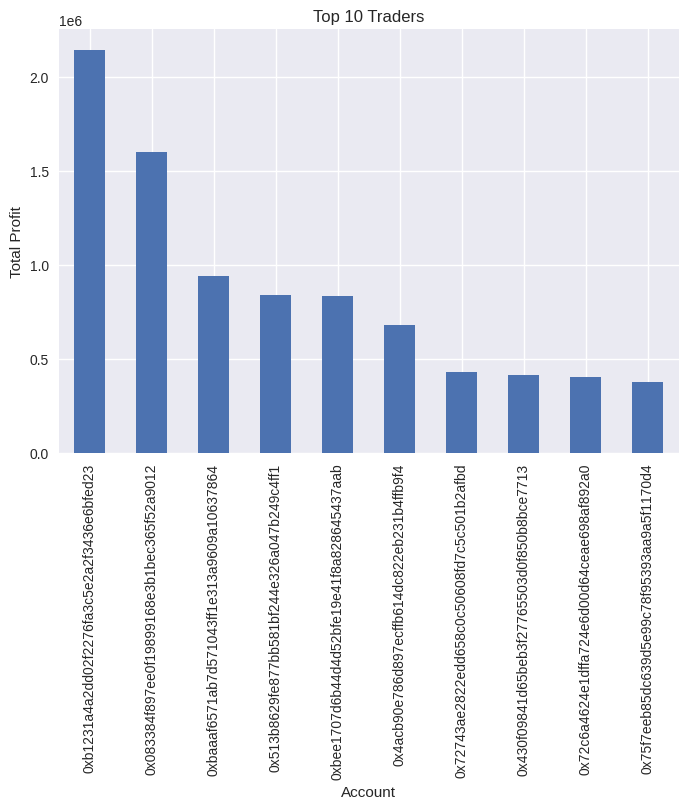

In [37]:
top_traders.plot(kind='bar')

plt.title('Top 10 Traders')
plt.ylabel('Total Profit')

plt.show()

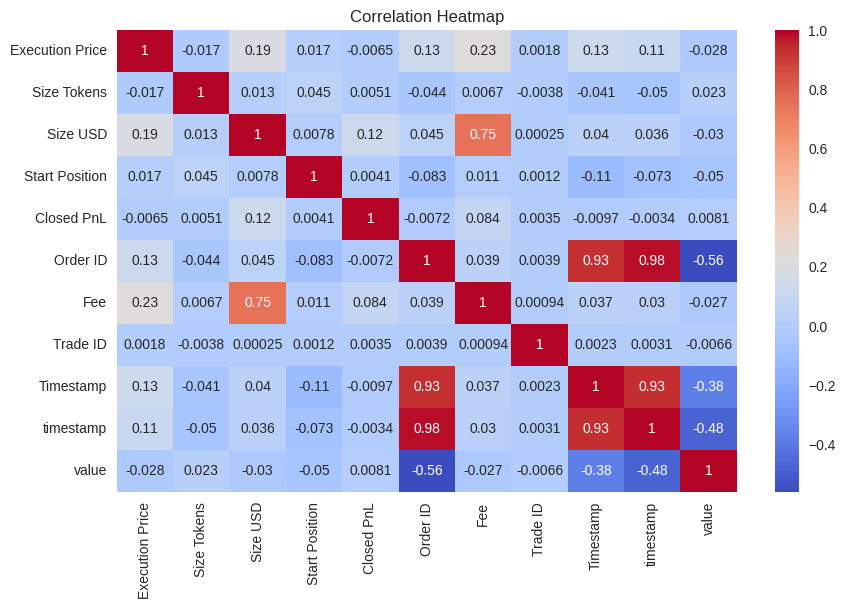

In [38]:
numeric_cols = merged.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()